# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Jaya Jaya Institut

# **Studi Kasus:** Jaya Jaya Institut

- Nama: Sandhika Hamzah
- Email: sanvinzah@gmail.com
- Id Dicoding: sandhika_hamzah_jvzn

## 1. Business Understanding
    



*   Konteks Bisnis:


    Jaya Jaya Institut adalah institusi pendidikan tinggi yang telah berdiri sejak tahun 2000. Meskipun memiliki reputasi yang sangat baik dan telah mencetak banyak lulusan, institusi ini menghadapi masalah internal yang cukup serius: **tingginya angka siswa yang tidak menyelesaikan pendidikan alias *dropout*.**
    
    



*   Problem Statement (Pernyataan Masalah):

    Tingkat *dropout* yang tinggi merugikan institusi secara finansial maupun reputasi, serta merugikan masa depan siswa itu sendiri. Manajemen seringkali terlambat menyadari bahwa seorang siswa akan melakukan *dropout* sehingga tidak ada tindakan preventif yang bisa dilakukan.
    
    

- Tujuan Proyek:

    1. **Analisis pola.** Menganalisis data historis mahasiswa (akademik, demografi, dan status ekonomi) untuk mengidentifikasi faktor utama penyebab dropout.
    2. **Deteksi dini.** Membangun model klasifikasi yang mampu menandai mahasiswa berisiko dropout sedini mungkin, sehingga institusi dapat memberikan bimbingan atau intervensi terarah.
    3. **Monitoring.** Menyediakan dashboard interaktif agar manajemen dapat memantau status dan performa mahasiswa secara berkelanjutan.

## Persiapan

Pustaka yang digunakan dikelompokkan ke dalam tiga kebutuhan: manipulasi data (`pandas`, `numpy`), visualisasi (`matplotlib`, `seaborn`), dan pemodelan (`scikit-learn`, `joblib`).

### Pustaka yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Pemodelan dan evaluasi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
# Konfigurasi gaya visualisasi
sns.set_theme(style='whitegrid')

### Sumber Data

Dataset berasal dari Jaya Jaya Institut dan memuat catatan historis mahasiswa, mencakup atribut demografi, latar belakang ekonomi, dan performa akademik per semester. Berkas disimpan dalam format CSV dengan pemisah titik koma, sehingga parameter `sep=';'` diperlukan pada saat pemuatan.

In [ ]:
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Tahap ini bertujuan memahami karakteristik data sebelum diolah lebih lanjut, mencakup:

- Pemeriksaan dimensi data, tipe setiap kolom, dan keberadaan nilai kosong.
- Peninjauan distribusi kolom target `Status` yang memiliki tiga kategori: `Dropout`, `Graduate`, dan `Enrolled`.
- Penelusuran hubungan awal antar variabel, khususnya antara status pelunasan biaya kuliah (`Tuition_fees_up_to_date`) dan tingkat dropout.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

/tmp/ipykernel_6352/3781417942.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='Set2')


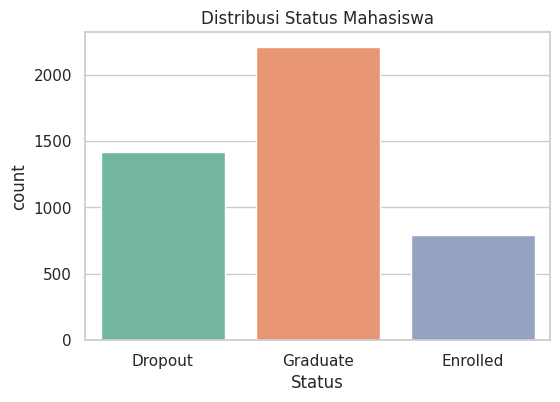

In [ ]:
# Ringkasan struktur data: dimensi, tipe kolom, dan kelengkapan nilai
df.info()
# Distribusi kelas target
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Distribusi Status Mahasiswa')
plt.show()

### Exploratory Data Analysis (Bivariate)

Analisis difokuskan pada dua dimensi yang paling relevan dengan tujuan bisnis: faktor finansial dan performa akademik tahun pertama. Kategori `Enrolled` dikeluarkan dari analisis ini karena statusnya belum final sehingga tidak dapat dibandingkan secara setara dengan `Dropout` maupun `Graduate`.

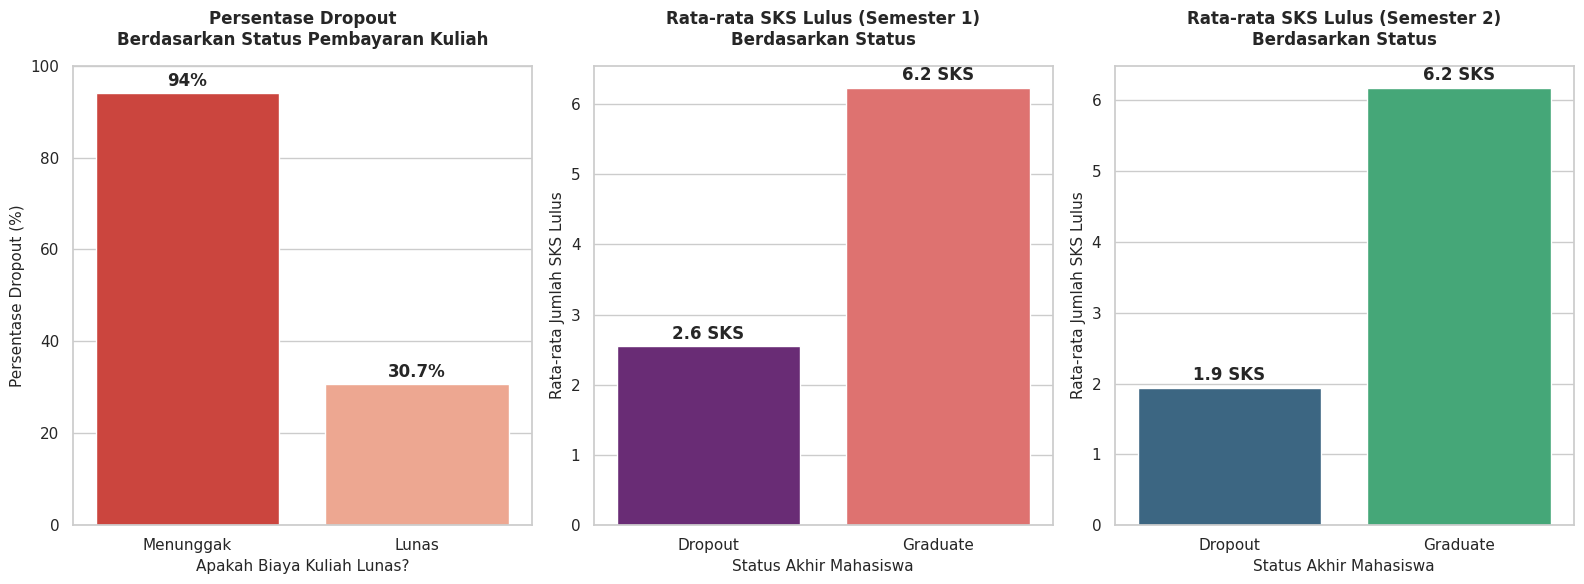

In [ ]:
df_eda = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

# PLOT 1: Hubungan Pembayaran Uang Kuliah dengan Persentase Dropout
plt.subplot(1, 3, 1)

tuition_crosstab = pd.crosstab(df_eda['Tuition_fees_up_to_date'], df_eda['Status'], normalize='index') * 100
dropout_rates = tuition_crosstab['Dropout']

ax1 = sns.barplot(
    x=dropout_rates.index,
    y=dropout_rates.values,
    hue=dropout_rates.index,
    palette='Reds_r',
    legend=False
)

plt.title('Persentase Dropout\nBerdasarkan Status Pembayaran Kuliah', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Apakah Biaya Kuliah Lunas?', fontsize=11)
plt.ylabel('Persentase Dropout (%)', fontsize=11)
plt.xticks([0, 1], ['Menunggak', 'Lunas'])
plt.ylim(0, 100)
for p in ax1.patches:
    val = p.get_height()
    if pd.notna(val) and val > 0:

        text_label = f'{val:.1f}'.replace('.0', '') + '%'

        ax1.annotate(text_label,
                     (p.get_x() + p.get_width() / 2., val),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points',
                     fontsize=12, fontweight='bold')

# PLOT 2: Performa Akademik (Rata-rata SKS Lulus di Semester 1) vs Status
plt.subplot(1, 3, 2)

ax2 = sns.barplot(
    data=df_eda,
    x='Status',
    y='Curricular_units_1st_sem_approved',
    hue='Status',
    estimator=np.mean,
    errorbar=None,
    palette='magma',
    legend=False
)

plt.title('Rata-rata SKS Lulus (Semester 1)\nBerdasarkan Status', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Status Akhir Mahasiswa', fontsize=11)
plt.ylabel('Rata-rata Jumlah SKS Lulus', fontsize=11)

for p in ax2.patches:
    val = p.get_height()
    if val.is_integer() or val % 1 == 0:
        text_label = f'{int(val)} SKS'
    else:
        text_label = f'{val:.1f} SKS'

    ax2.annotate(text_label,
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha = 'center', va = 'center',
                 xytext = (0, 9),
                 textcoords = 'offset points',
                 fontsize=12, fontweight='bold')

# PLOT 3: Performa Akademik (Rata-rata SKS Lulus di Semester 2) vs Status
plt.subplot(1, 3, 3)

ax3 = sns.barplot(
    data=df_eda,
    x='Status',
    y='Curricular_units_2nd_sem_approved',
    hue='Status',
    estimator=np.mean,
    errorbar=None,
    palette='viridis',
    legend=False
)

plt.title('Rata-rata SKS Lulus (Semester 2)\nBerdasarkan Status', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Status Akhir Mahasiswa', fontsize=11)
plt.ylabel('Rata-rata Jumlah SKS Lulus', fontsize=11)

for p in ax3.patches:
    val = p.get_height()
    if val.is_integer() or val % 1 == 0:
        text_label = f'{int(val)} SKS'
    else:
        text_label = f'{val:.1f} SKS'

    ax3.annotate(text_label,
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha = 'center', va = 'center',
                 xytext = (0, 9),
                 textcoords = 'offset points',
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**

1. **Faktor Finansial (Sangat Kritis):** Dari grafik pertama, terlihat sangat jelas bahwa mahasiswa yang menunggak biaya kuliah (nilai 0) memiliki persentase putus kuliah (*dropout*) yang sangat ekstrim, yakni mencapai **94%**. Sebaliknya, mahasiswa yang lunas biaya kuliahnya memiliki risiko *dropout* yang jauh lebih kecil. Ini memvalidasi hipotesis bahwa masalah finansial adalah akar penyebab utama kasus *dropout* di institusi ini.

2. **Faktor Akademik (Sinyal Peringatan Dini):**
   Dari grafik kedua dan ketiga, terdapat perbedaan performa yang sangat jomplang antara kelompok yang lulus (*Graduate*) dan yang *dropout*. Mahasiswa yang akhirnya *dropout* rata-rata hanya mampu meluluskan sekitar **2,6 SKS** disemester 1 dan **1,9 SKS** di semester 2, jauh di bawah mahasiswa yang berhasil lulus. Hal ini mengindikasikan bahwa mahasiswa yang berpotensi *dropout* sudah menunjukkan tanda-tanda "kegagalan akademik" atau kesulitan mengikuti perkuliahan sejak tahun pertama (semester 1 dan 2).


## Data Preparation / Preprocessing

Data mentah memerlukan sejumlah penyesuaian sebelum dapat digunakan untuk pemodelan. Tahapan yang diterapkan:

1. **Penanganan nilai kosong.** Jika ditemukan data kosong, penanganan dilakukan melalui pembuangan baris atau pengisian dengan nilai median (numerik) dan modus (kategorik).
2. **Encoding target.** Kolom `Status` bertipe teks, sedangkan algoritma klasifikasi memerlukan masukan numerik. Karena fokus proyek adalah deteksi dropout, target disederhanakan menjadi klasifikasi biner: `Dropout` bernilai 1 dan `Graduate` bernilai 0.
3. **Standardisasi skala.** Rentang nilai antar kolom disamakan agar tidak ada fitur yang mendominasi semata-mata karena perbedaan satuan.

In [ ]:
# Subset pada kelas terminal; 'Enrolled' dikeluarkan karena statusnya belum final
df_clean = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
# Encoding target menjadi biner: Dropout = 1, Graduate = 0
df_clean['Status_Encoded'] = df_clean['Status'].apply(lambda x: 1 if x == 'Dropout' else 0)
# Pemisahan fitur dan target
X = df_clean.drop(['Status', 'Status_Encoded'], axis=1)
y = df_clean['Status_Encoded']
# Standardisasi skala fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Modeling

Pemodelan dilakukan untuk mengenali pola yang menandakan risiko dropout berdasarkan kombinasi atribut akademik, finansial, dan demografi.

Data dibagi menjadi data latih dan data uji dengan proporsi 80:20. Algoritma yang dipilih adalah **Random Forest Classifier**, dengan dua pertimbangan: performanya baik pada data tabular dengan banyak fitur heterogen, dan algoritma ini menyediakan skor *feature importance* yang dapat ditelusuri untuk mengidentifikasi pemicu utama dropout.

In [ ]:
# Pembagian data latih dan data uji (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
# Inisialisasi model
model = RandomForestClassifier(n_estimators=100, random_state=42)
# Pelatihan model pada data latih
model.fit(X_train, y_train)
# Prediksi pada data uji
y_pred = model.predict(X_test)

## Evaluation

Evaluasi model tidak cukup dinilai dari akurasi keseluruhan. Untuk kasus ini, metrik **recall pada kelas Dropout** menjadi prioritas.

Alasannya terletak pada asimetri biaya kesalahan. Kesalahan tipe *false positive* (mahasiswa diprediksi berisiko padahal aman) hanya berdampak pada alokasi bimbingan yang berlebih. Sebaliknya, *false negative* (mahasiswa diprediksi aman padahal akhirnya dropout) berarti institusi kehilangan kesempatan melakukan intervensi. Karena tujuan sistem adalah pencegahan, kesalahan tipe kedua jauh lebih mahal.

--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

Graduate (0)       0.90      0.95      0.92       449
 Dropout (1)       0.92      0.82      0.87       277

    accuracy                           0.90       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.90      0.90      0.90       726

\n--- Confusion Matrix ---


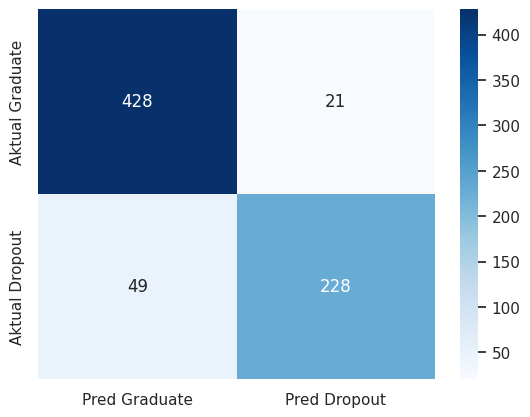

In [ ]:
print('--- Laporan Klasifikasi ---')
print(classification_report(y_test, y_pred, target_names=['Graduate (0)', 'Dropout (1)']))
print('\\n--- Confusion Matrix ---')
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Graduate', 'Pred Dropout'], yticklabels=['Aktual Graduate', 'Aktual Dropout'])
plt.show()

In [ ]:
# Serialisasi model terlatih
joblib.dump(model, 'rf_model.joblib')
print("Model berhasil disimpan sebagai 'rf_model.joblib'")

# Serialisasi objek scaler untuk konsistensi praproses saat inferensi
joblib.dump(scaler, 'scaler.joblib')
print("Scaler berhasil disimpan sebagai 'scaler.joblib'")

Model berhasil disimpan sebagai 'rf_model.joblib'
Scaler berhasil disimpan sebagai 'scaler.joblib'


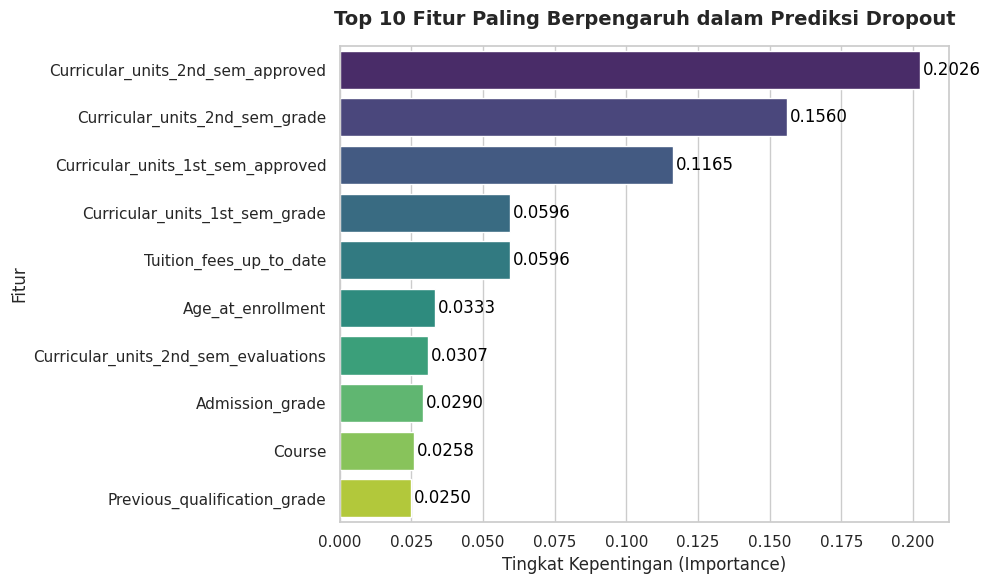

In [ ]:
# Ekstraksi sepuluh fitur dengan kontribusi terbesar terhadap prediksi
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances_sorted = feature_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=feature_importances_sorted.values,
    y=feature_importances_sorted.index,
    hue=feature_importances_sorted.index,
    palette='viridis',
    legend=False
)

plt.title('Top 10 Fitur Paling Berpengaruh dalam Prediksi Dropout', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tingkat Kepentingan (Importance)', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
for i, v in enumerate(feature_importances_sorted.values):
    plt.text(v + 0.001, i, f"{v:.4f}", color='black', va='center')

plt.tight_layout()
plt.show()

**Insight Feature Importance:**

Berdasarkan model Random Forest yang dilatih, 3 fitur yang paling memengaruhi keputusan (status) akhir seorang mahasiswa adalah:
1. SKS yang berhasil diluluskan pada Semester 2 (`Curricular_units_2nd_sem_approved`).
2. SKS yang berhasil diluluskan pada Semester 1 (`Curricular_units_1st_sem_approved`).
3. Status pelunasan biaya kuliah (`Tuition_fees_up_to_date`).

Hal ini sangat sejalan dengan temuan pada analisis Bivariate (EDA), di mana masalah finansial dan performa akademik di tahun pertama adalah faktor prediktor terkuat untuk mendeteksi potensi *dropout*.
